# Figure 6 — Dimension ablation

Prediction accuracy and similarity variance-explained as dimensions are removed. Needs the ablation cache: `python scripts/build_cache.py`.

In [1]:
# Make the things_spose package importable whether this runs from src/ or
# src/notebooks/ (jupyter lab vs papermill/nbconvert set different cwds).
import sys, pathlib
for _c in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_c / "things_spose").is_dir():
        sys.path.insert(0, str(_c)); break

import matplotlib.pyplot as plt
from things_spose.core import backend
from things_spose.data import dataio
print(backend.describe())
ds = dataio.load_dataset()
SAVE = False  # set True to export SVGs next to this notebook

device=cpu (kind=cpu), num_workers=8, similarity_backend=numba


/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


9-14 dims for 95-99% accuracy; 9-15 dims for 95-99% variance


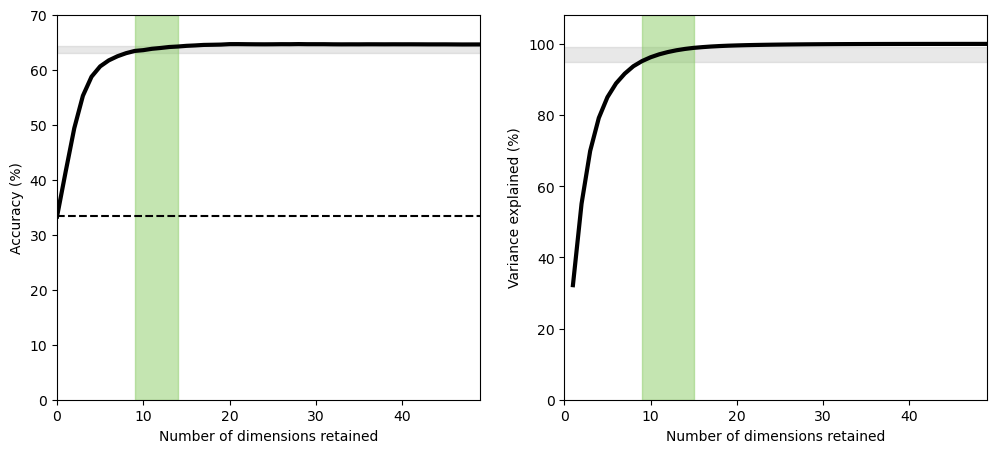

In [2]:
from things_spose.analysis import analyses, viz
from things_spose.core import artifacts
cache = artifacts.load_ablation_cache()
pred = analyses.predict_triplets(ds.dot_product, ds.triplets_test, ds.n_objects)
abl = analyses.dimension_ablation(cache.reduced_embeddings, None, ds.spose_sim,
        ds.triplets_test, pred.accuracy, reduced_sim_pairvecs=cache.reduced_sim_pairvecs)
print(f'{abl.mindim_acc}-{abl.maxdim_acc} dims for 95-99% accuracy; '
      f'{abl.mindim_var}-{abl.maxdim_var} dims for 95-99% variance')
fig = viz.fig6_ablation(abl, save_path='fig6.svg' if SAVE else None)
plt.show()